# Telecom Customer Churn Prediction using Ensemble Learning
  
## Model: Random Forest Classifier  

---

## Project Objective
### To develop a robust classification model that predicts customer churn by:
- Optimizing model parameters
- Evaluating performance using multiple metrics
- Identifying key influencing features

---

## Approach
### This project leverages:
- Pre-divided dataset (train & test)
- Ensemble learning techniques
- Statistical validation (cross-validation)


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import RandomizedSearchCV, cross_validate
from sklearn.metrics import confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Reading datasets
df_train = pd.read_csv("churn-bigml-80.csv")
df_test  = pd.read_csv("churn-bigml-20.csv")

print(f"Training Data: {df_train.shape}")
print(f"Testing Data: {df_test.shape}")

Training Data: (2666, 20)
Testing Data: (667, 20)


In [3]:
df_train.describe(include='all')

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
count,2666,2666.000000,2666.000000,2666,2666,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666
unique,51,NaN,NaN,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,WV,NaN,NaN,No,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
freq,88,NaN,NaN,2396,1933,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2278
mean,NaN,100.620405,437.438860,NaN,NaN,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641,NaN
std,NaN,39.563974,42.521018,NaN,NaN,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236,NaN
min,NaN,1.000000,408.000000,NaN,NaN,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,73.000000,408.000000,NaN,NaN,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000,NaN
50%,NaN,100.000000,415.000000,NaN,NaN,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000,NaN
75%,NaN,127.000000,510.000000,NaN,NaN,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000,NaN


## Merging datasets to ensure uniform transformations

In [4]:
data = pd.concat([df_train, df_test], ignore_index=True)

## Data Preparation

In [5]:
# Handling duplicates
data.drop_duplicates(inplace=True)

# Fill missing values smartly
for column in data.columns:
    if data[column].dtype == 'object':
        data[column].fillna(data[column].value_counts().idxmax(), inplace=True)
    else:
        data[column].fillna(data[column].median(), inplace=True)

## Transforming Categorical Variables

In [6]:
# Binary conversion
binary_map = {'Yes': 1, 'No': 0}
data.replace(binary_map, inplace=True)

# Encoding categorical variables
encoder = LabelEncoder()

categorical_cols = data.select_dtypes(include='object').columns

for col in categorical_cols:
    data[col] = encoder.fit_transform(data[col])

## Define Inputs & Output

In [7]:
target = 'Churn'

features = data.drop(columns=[target])
labels = data[target]

## Train-Test Split

In [8]:
split_index = len(df_train)

X_train = features.iloc[:split_index]
X_test  = features.iloc[split_index:]

y_train = labels.iloc[:split_index]
y_test  = labels.iloc[split_index:]

## Model Setup

In [9]:
model = RandomForestClassifier(
    random_state=42,
    class_weight='balanced_subsample'
)

## Parameter Search using Random Sampling

In [10]:
param_grid = {
    'n_estimators': np.arange(100, 600, 100),
    'max_depth': [None, 15, 25, 35],
    'min_samples_split': [2, 4, 8],
    'min_samples_leaf': [1, 2, 3]
}

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=15,
    cv=4,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

optimized_model = search.best_estimator_

Fitting 4 folds for each of 15 candidates, totalling 60 fits


## Validation Scores

In [11]:
cv_results = cross_validate(
    optimized_model,
    X_train,
    y_train,
    cv=5,
    scoring=['accuracy', 'f1']
)

print("Average Accuracy:", cv_results['test_accuracy'].mean())
print("Average F1 Score:", cv_results['test_f1'].mean())

Average Accuracy: 0.9471102023034058
Average F1 Score: 0.8051912180397272


## Predictions

In [12]:
predictions = optimized_model.predict(X_test)

## Performance Report

In [13]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

       False       0.97      0.99      0.98       572
        True       0.90      0.80      0.85        95

    accuracy                           0.96       667
   macro avg       0.94      0.89      0.91       667
weighted avg       0.96      0.96      0.96       667



## Confusion Matrix

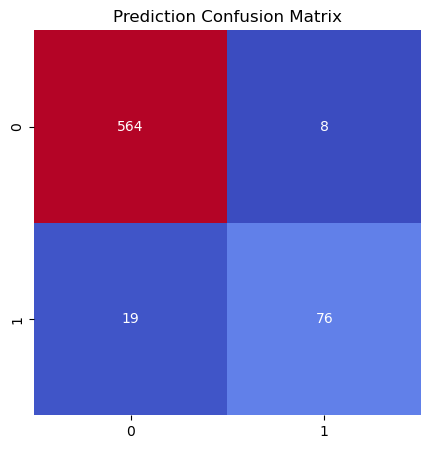

In [14]:
cmatrix = confusion_matrix(y_test, predictions)

plt.figure(figsize=(5,5))
sns.heatmap(cmatrix, annot=True, fmt='d', cmap='coolwarm', cbar=False)
plt.title("Prediction Confusion Matrix")
plt.show()

## Feature Importance

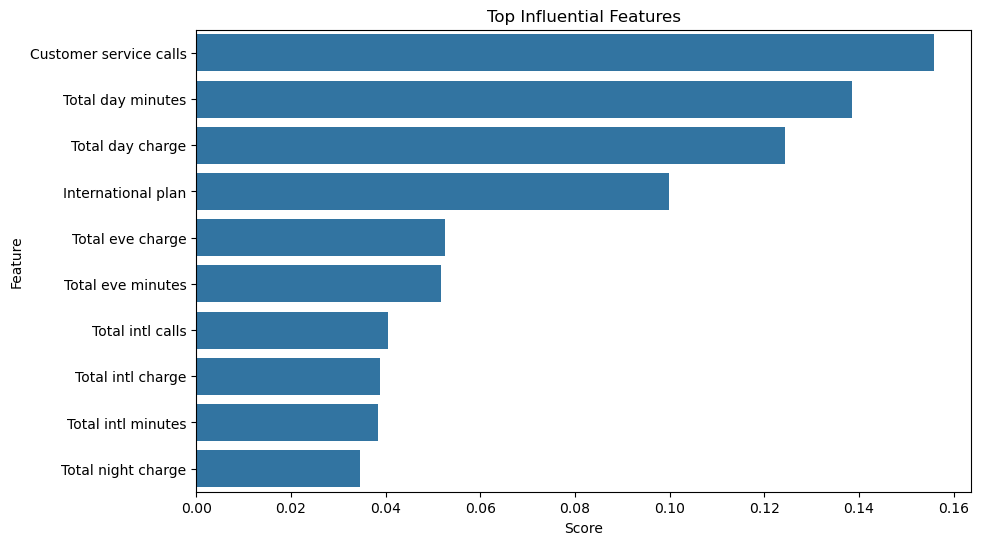

In [15]:
importance = pd.DataFrame({
    'Feature': features.columns,
    'Score': optimized_model.feature_importances_
}).sort_values(by='Score', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Score', y='Feature', data=importance.head(10))
plt.title("Top Influential Features")
plt.show()

## Observations

- Ensemble learning significantly boosts predictive performance.
- Hyperparameter tuning refines model efficiency.
- Key features strongly influence churn behavior.
- Model generalizes well due to cross-validation.

---

## Summary

This implementation:

1 Uses optimized ensemble learning  
2 Applies structured preprocessing  
3 Validates performance rigorously  
4 Provides business insights  
